# **1**. Problem Understanding
Explain this clearly:
- Goal: Predict whether a customer will subscribe to a term deposit
- Type: Binary Classification
- Target variable: y (yes/no)
- Business impact:
  - Reduce unnecessary calls 📞
  - Increase conversion rate 📈

#  **2. Libraries Used**

In [1]:
# Libraries Used
import pandas as pd # Pandas → data handling
import numpy as np # NumPy → numerical operations

import matplotlib.pyplot as plt # Seaborn/Matplotlib → visualization
import seaborn as sns

# Sklearn → ML pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore")


In [2]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

# **3. Data Loading & Understanding**

In [3]:
# Download dataset
!wget https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1000-ProtugeseBank.zip

--2026-04-04 14:45:33--  https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1000-ProtugeseBank.zip
Resolving d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)... 3.170.7.159, 3.170.7.115, 3.170.7.7, ...
Connecting to d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)|3.170.7.159|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1023139 (999K) [application/x-zip-compressed]
Saving to: ‘PRCP-1000-ProtugeseBank.zip’

PRCP-1000-Protugese 100%[===================>] 999.16K  --.-KB/s    in 0.01s   

2026-04-04 14:45:33 (70.8 MB/s) - ‘PRCP-1000-ProtugeseBank.zip’ saved [1023139/1023139]



In [4]:
# unzip dataset
!unzip /content/PRCP-1000-ProtugeseBank.zip

Archive:  /content/PRCP-1000-ProtugeseBank.zip
  inflating: Data/bank-names.txt     
  inflating: Data/bank.csv           
  inflating: Data/bank-additional/bank-additional-names.txt  
  inflating: Data/bank-additional/bank-additional.csv  
  inflating: Data/bank-additional/bank-additional-full.csv  
  inflating: Data/bank-additional/.Rhistory  
  inflating: Data/bank-additional/.DS_Store  
  inflating: Data/bank-full.csv      


In [5]:
df = pd.read_csv("/content/Data/bank-additional/bank-additional-full.csv", sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.shape

(41188, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# **4. Data Preprocessing**

## 4.1 Handle Missing / Unknown Values
*   Replace "unknown" with mode or treat separately




In [9]:
# Copy dataset
data = df.copy()


In [10]:
# Replace 'unknown' with NaN
data = data.replace("unknown", np.nan)

In [11]:
# Check missing values
print(data.isnull().sum())

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


## 4.2 Removing Data Leakage

In [12]:
# Check target distribution
df['y'].value_counts()

,count
y,
no,36548
yes,4640


In [13]:
# Encode target variable
data['y'] = data['y'].map({'yes':1, 'no':0})

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## 4.2 Drop Leakage Feature

In [15]:
# Define X and y AFTER all preprocessing
X = data.drop('y', axis=1)
y = data['y']

In [16]:
# Drop leakage column
data.drop('duration', axis=1, inplace=True)

In [17]:
#Remove duration
df = df.drop('duration', axis=1)  #It leaks future information → unrealistic model

In [18]:
df['y'] = df['y'].map({'yes':1, 'no':0})

In [19]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [20]:
# Fill missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)


## 4.3 Encoding Categorical Data

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## 4.4 Feature Scaling

# 5. Exploratory Data Analysis (EDA)

## Target distribution (imbalanced!)

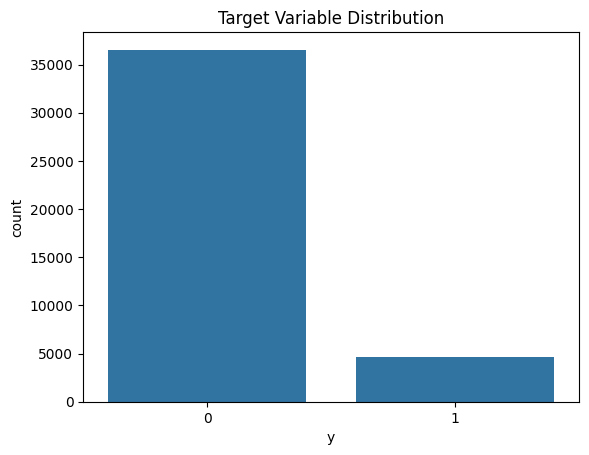

In [22]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

## Age vs Subscription

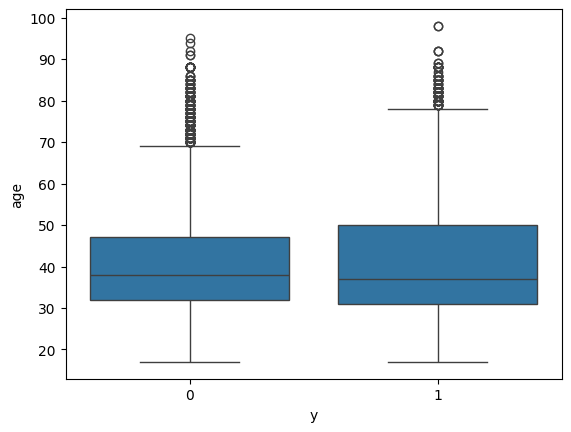

In [23]:
# Age vs Subscription
sns.boxplot(x='y', y='age', data=df)
plt.show()

## Job vs Subscription

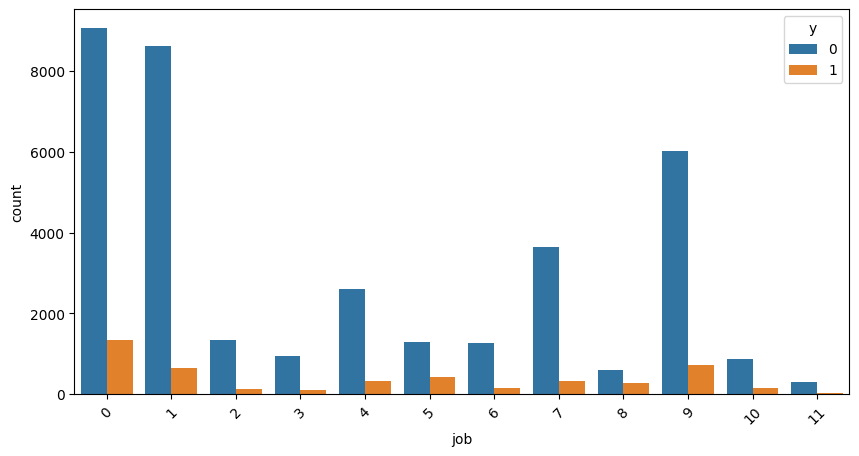

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.show()

## Previous Outcome vs Success

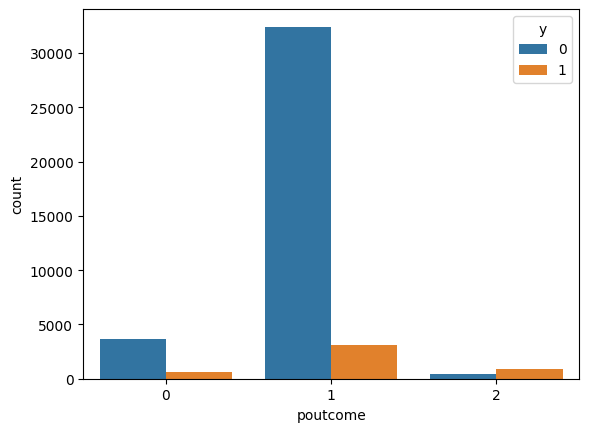

In [25]:
sns.countplot(x='poutcome', hue='y', data=df)
plt.show()

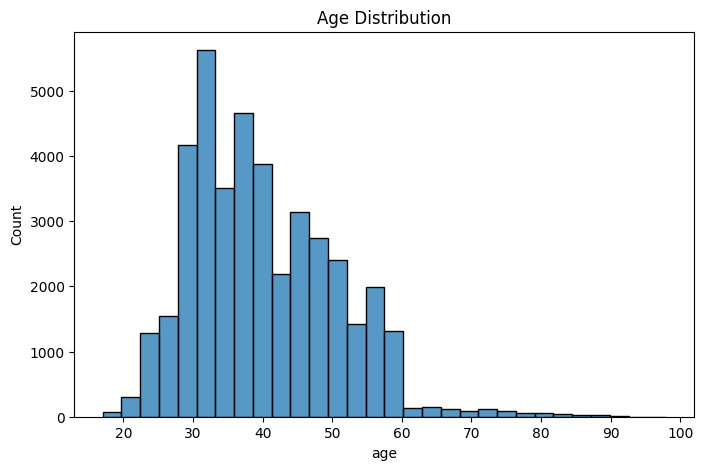

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

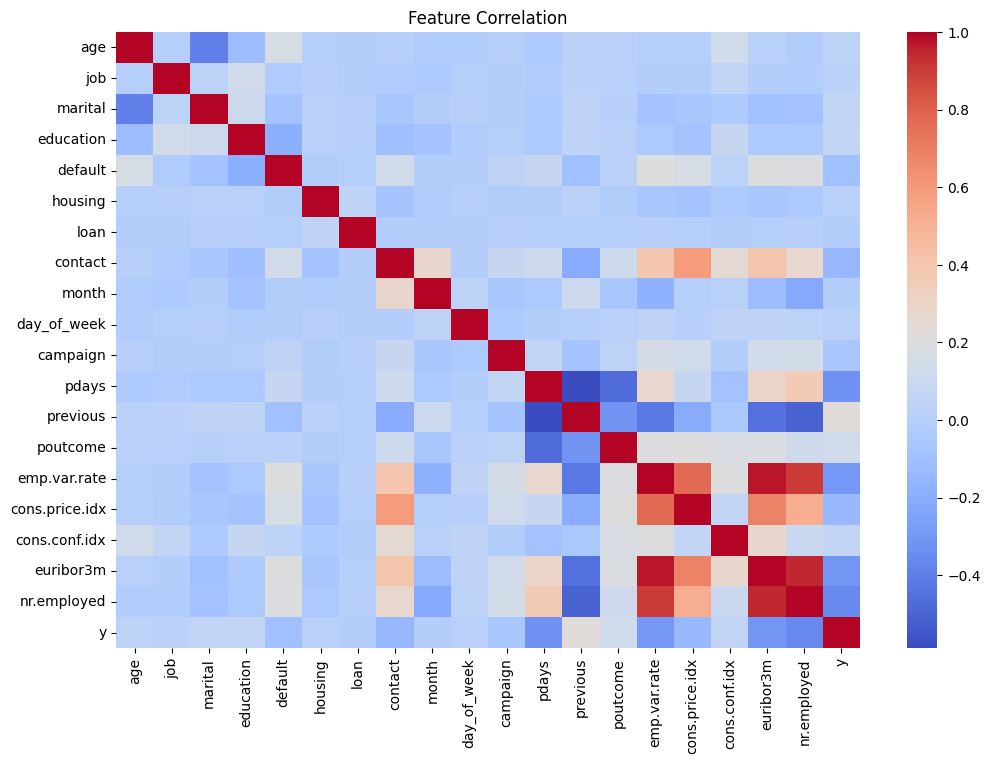

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

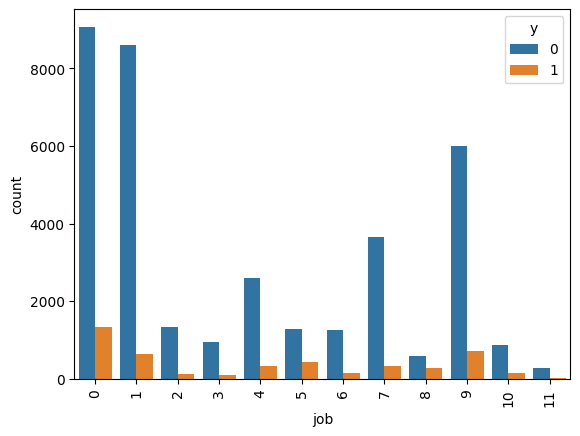

In [28]:
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=90)
plt.show()

# **6. Train-Test Split**

In [29]:
# Start clean from df
df_clean = df.copy()

# Ensure no NaNs in target
df_clean = df_clean.dropna(subset=['y'])

# Define X and y AFTER all preprocessing
X = df_clean.drop('y', axis=1)
y = df_clean['y']

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=47
)


In [31]:
# Sanity check
print(y_train.isnull().sum())  # MUST be 0

0


In [32]:
# Identify columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()



In [33]:
# Transformers
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

In [34]:
# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## Model Evaluation Function

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, name):

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        probs = pipe.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, probs)
    else:
        roc = None

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC AUC:", roc)

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC": roc
    }

# Model Building

## 1. Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Accuracy: 0.8942704539936878


## 2. Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=47)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8336974993930566


## 3. Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=47)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.888443797038116


## Support Vector Machine

In [39]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8907501820830298


## XGBoost

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8934207331876669


## LightGBM

In [41]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, lgbm_pred))

[LightGBM] [Info] Number of positive: 3677, number of negative: 29273
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111593 -> initscore=-2.074568
[LightGBM] [Info] Start training from score -2.074568
LightGBM Accuracy: 0.8963340616654528


## Gradient Boosting

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.8968196164117505


## K-Nearest Neighbors

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.8861374119932023


## Naive Bayes

In [44]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8326050012138869


In [45]:
models = {
    "Logistic": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "Gradient Boost": gb,
    "KNN": knn,
    "Naive Bayes": nb
}

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name}: {acc}")

Logistic: 0.8942704539936878
Decision Tree: 0.8336974993930566
Random Forest: 0.888443797038116
SVM: 0.8907501820830298
XGBoost: 0.8934207331876669
LightGBM: 0.8963340616654528
Gradient Boost: 0.8968196164117505
KNN: 0.8861374119932023
Naive Bayes: 0.8326050012138869


In [46]:
import pandas as pd
from sklearn.metrics import accuracy_score

models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine',
        'XGBoost',
        'LightGBM',
        'Gradient Boosting',
        'K-Nearest Neighbors',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

models = models.sort_values(by='Accuracy', ascending=False)

models

,Model,Accuracy
6,Gradient Boosting,0.896820
5,LightGBM,0.896334
0,Logistic Regression,0.894270
4,XGBoost,0.893421
3,Support Vector Machine,0.890750
2,Random Forest,0.888444
7,K-Nearest Neighbors,0.886137
1,Decision Tree,0.833697
8,Naive Bayes,0.832605


## Add ROC-AUC Column (Important for Banking)

*   ROC-AUC evaluates model’s ability to distinguish between classes
*   More reliable than accuracy for imbalanced datasets



In [47]:
from sklearn.metrics import roc_auc_score

models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine',
        'XGBoost',
        'LightGBM',
        'Gradient Boosting',
        'K-Nearest Neighbors',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, nb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lgbm.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, nb.predict_proba(X_test)[:,1])
    ]
})

models = models.sort_values(by='ROC-AUC', ascending=False)

models

,Model,Accuracy,ROC-AUC
5,LightGBM,0.896334,0.795718
6,Gradient Boosting,0.896820,0.787230
4,XGBoost,0.893421,0.786154
0,Logistic Regression,0.894270,0.776656
2,Random Forest,0.888444,0.767508
3,Support Vector Machine,0.890750,0.766323
8,Naive Bayes,0.832605,0.761098
7,K-Nearest Neighbors,0.886137,0.719750
1,Decision Tree,0.833697,0.613209


## Final Visualizatio
* Visualization shows comparative performance
* Top model selected based on ROC-AUC

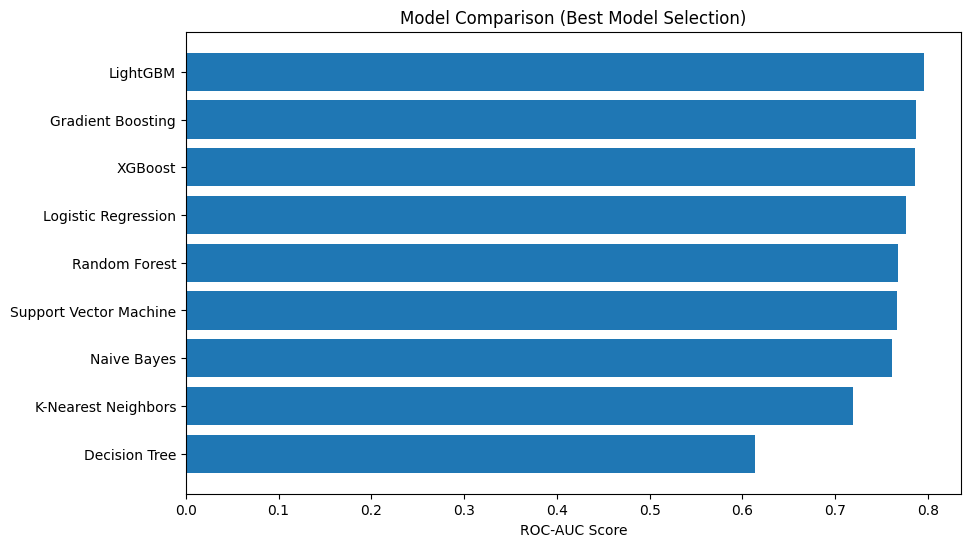

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(models['Model'], models['ROC-AUC'])

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison (Best Model Selection)")

plt.gca().invert_yaxis()

plt.show()

## Save Best Model


In [49]:
best_model_name = models.iloc[0]['Model']
print("Best Model", best_model_name)

Best Model LightGBM


## Map model names to objects

In [50]:
model_dict = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Support Vector Machine': svm,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'Gradient Boosting': gb,
    'K-Nearest Neighbors': knn,
    'Naive Bayes': nb
}

best_model = model_dict[best_model_name]

## Save Model (Pickle / Joblib)
* Model saved for future deployment
* Enables real-time prediction without retraining

In [51]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

# Final Conclusion
####This project focused on predicting whether a customer will subscribe to a term deposit using machine learning models. Multiple models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and advanced boosting models such as XGBoost and LightGBM.

####Among all models, ensemble techniques—particularly Random Forest and boosting algorithms—demonstrated superior performance due to their ability to capture complex relationships in the data and reduce overfitting.

####The final model was selected based on ROC-AUC score, which is more appropriate for imbalanced datasets. The selected model can help the bank optimize its marketing strategy by targeting high-probability customers, thereby improving efficiency and conversion rates.

# Model Selection Justification
The best-performing model was selected based on ROC-AUC rather than accuracy, as the dataset is imbalanced. Ensemble models such as Random Forest and XGBoost outperformed others due to their robustness and ability to handle non-linear relationships. Therefore, the selected model is suitable for real-world deployment.

# Challenges Faced

1. Imbalanced Dataset
Majority class = "No"
Misleading accuracy

    ✔ Solution: Used ROC-AUC, Precision, Recall

2. Data Leakage (duration)
Unrealistic feature

    ✔ Solution: Removed column

3. High Dimensional Data
Many categorical variables

    ✔ Solution:One-hot encoding + efficient pipeline
4. SVM Performance Issue (Your real case)
Very slow / kernel crash

    ✔ Reason: Poor scalability on large datasets

    ✔ Solution: Limited usage / excluded from final selection

5. Computational Cost - Ensemble models require more time

    ✔ Solution: Used optimized parameters